# Language Model

The main goal of language model is to estimate the joint probability of the sequence :

$P(x_1, x_2, \ldots, x_T)$

For instance, the phrases “to recognize speech” and “to wreck a nice beach” sound very similar. This can cause ambiguity in speech recognition, which is easily resolved through a language model that rejects the second translation as outlandish.
In a document summarization algorithm it is worthwhile knowing that “dog bites man” is much more frequent than “man bites dog”, or that “I want to eat grandma” is a rather disturbing statement, whereas “I want to eat, grandma” is much more benign.

In [1]:
# Imports

import torch

Basic Probability Rule :

$$
P(x_1, x_2, \ldots, x_T) = \prod_{t=1}^T P(x_t  \mid  x_1, \ldots, x_{t-1}).
$$

$$
\begin{split}\begin{aligned}&P(\textrm{deep}, \textrm{learning}, \textrm{is}, \textrm{fun}) = P(\textrm{deep}) P(\textrm{learning}  \mid  \textrm{deep}) P(\textrm{is}  \mid  \textrm{deep}, \textrm{learning}) P(\textrm{fun}  \mid  \textrm{deep}, \textrm{learning}, \textrm{is}).\end{aligned}\end{split}
$$

A distribution over sequences satisfies the Markov property of first order if $P(x_{t+1} \mid x_t, \ldots, x_1) = P(x_{t+1} \mid x_t)$. Higher orders correspond to longer dependencies. This leads to a number of approximations that we could apply to model a sequence: 

$$
\begin{split}\begin{aligned}
P(x_1, x_2, x_3, x_4) &=  P(x_1) P(x_2) P(x_3) P(x_4),\\
P(x_1, x_2, x_3, x_4) &=  P(x_1) P(x_2  \mid  x_1) P(x_3  \mid  x_2) P(x_4  \mid  x_3),\\
P(x_1, x_2, x_3, x_4) &=  P(x_1) P(x_2  \mid  x_1) P(x_3  \mid  x_1, x_2) P(x_4  \mid  x_2, x_3).
\end{aligned}\end{split}
$$

Unigram, Bigram and Trigram

## Laplace Smoothing

$$
\begin{split}\begin{aligned}
    \hat{P}(x) & = \frac{n(x) + \epsilon_1/m}{n + \epsilon_1}, \\
    \hat{P}(x' \mid x) & = \frac{n(x, x') + \epsilon_2 \hat{P}(x')}{n(x) + \epsilon_2}, \\
    \hat{P}(x'' \mid x,x') & = \frac{n(x, x',x'') + \epsilon_3 \hat{P}(x'')}{n(x, x') + \epsilon_3}.
\end{aligned}\end{split}
$$

Adds a paramter $\alpha$ in general to the probability function in order to add non zero probability to the non observed n-gram sequences so that model is robust. It also slightly lowers the probability of observed (seen) sequences during the training. 

If $\alpha == 1$ then it is called laplace smoothing
else If $0 < \alpha < 1$ then it is called lindstone smoothing

General formula : 

$$
P(w_n \mid w_{n-1}, \ldots, w_1)
=
\frac{C(w_1,\ldots,w_n)+\alpha}
{C(w_1,\ldots,w_{n-1})+\alpha \cdot V}
$$

## Perplexity

$$
\exp\left(-\frac{1}{n} \sum_{t=1}^n \log P(x_t \mid x_{t-1}, \ldots, x_1)\right).
$$

Perplexity can be best understood as the reciprocal of the geometric mean of the number of real choices that we have when deciding which token to pick next. Let’s look at a number of cases:

- In the best case scenario, the model always perfectly estimates the probability of the target token as 1. In this case the perplexity of the model is 1.
- In the worst case scenario, the model always predicts the probability of the target token as 0. In this situation, the perplexity is positive infinity.
- At the baseline, the model predicts a uniform distribution over all the available tokens of the vocabulary. In this case, the perplexity equals the number of unique tokens of the vocabulary. In fact, if we were to store the sequence without any compression, this would be the best we could do for encoding it. Hence, this provides a nontrivial upper bound that any useful model must beat.

(source D2L.ai)

## Partitioning Sequences

This is the proposed sequence of partitioning to be done.

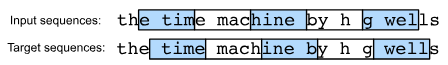